2026-04-14 13:16:39.672470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776172599.915548      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776172599.989620      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776172600.563864      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776172600.563916      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776172600.563919      23 computation_placer.cc:177] computation placer alr

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (40000, 3072), Val: (10000, 3072), Test: (10000, 3072)
Training with LR=0.0001, epochs=10


I0000 00:00:1776172638.095131      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1776172642.166526      66 service.cc:152] XLA service 0x7db1840067a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776172642.166565      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776172642.500463      66 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776172644.404486      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Training with LR=0.0001, epochs=20
Training with LR=0.0001, epochs=30
Training with LR=0.0001, epochs=50
Training with LR=0.001, epochs=10
Training with LR=0.001, epochs=20
Training with LR=0.001, epochs=30
Training with LR=0.001, epochs=50
Training with LR=0.01, epochs=10
Training with LR=0.01, epochs=20
Training with LR=0.01, epochs=30
Training with LR=0.01, epochs=50
Training with LR=0.1, epochs=10
Training with LR=0.1, epochs=20
Training with LR=0.1, epochs=30
Training with LR=0.1, epochs=50


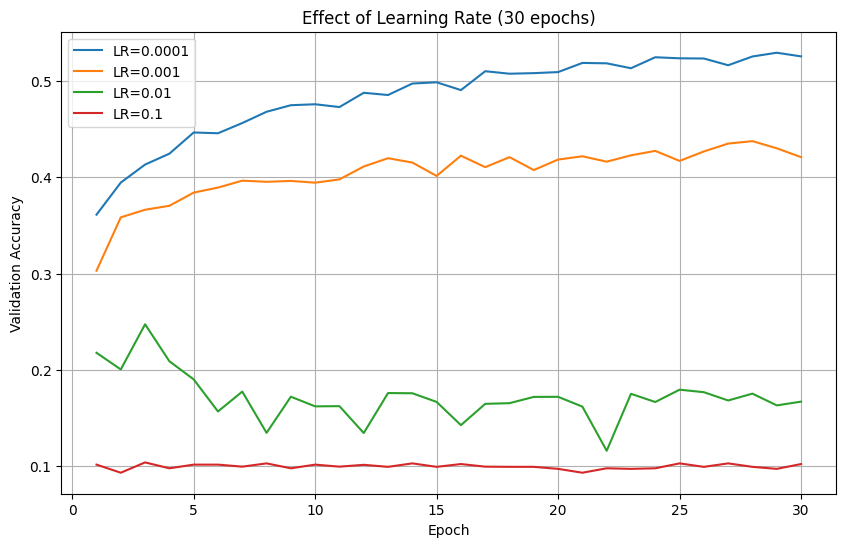

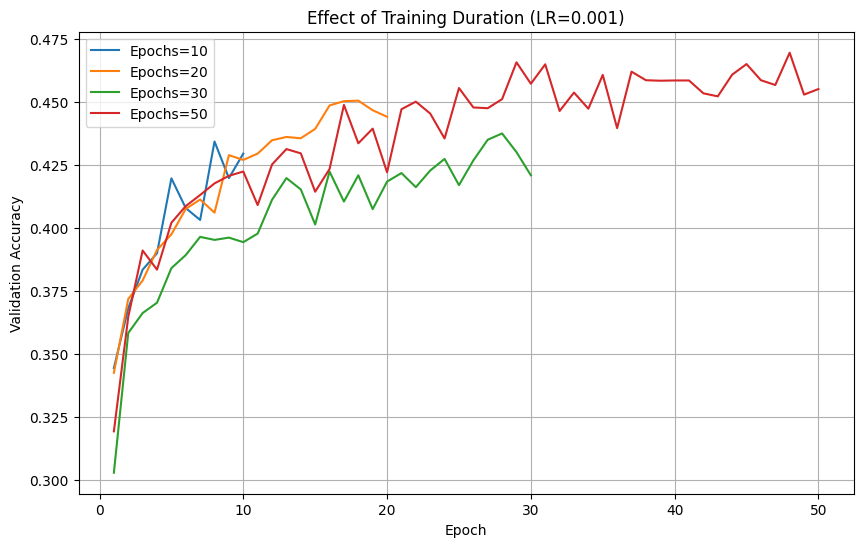

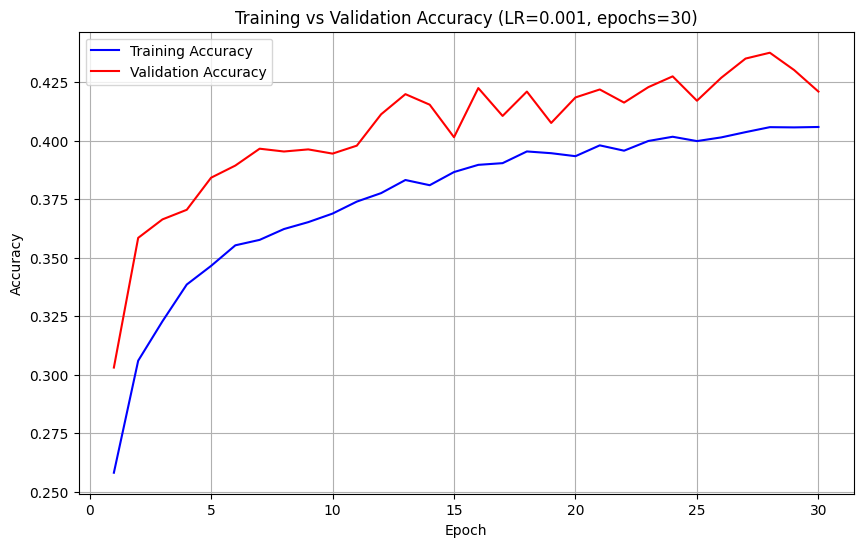

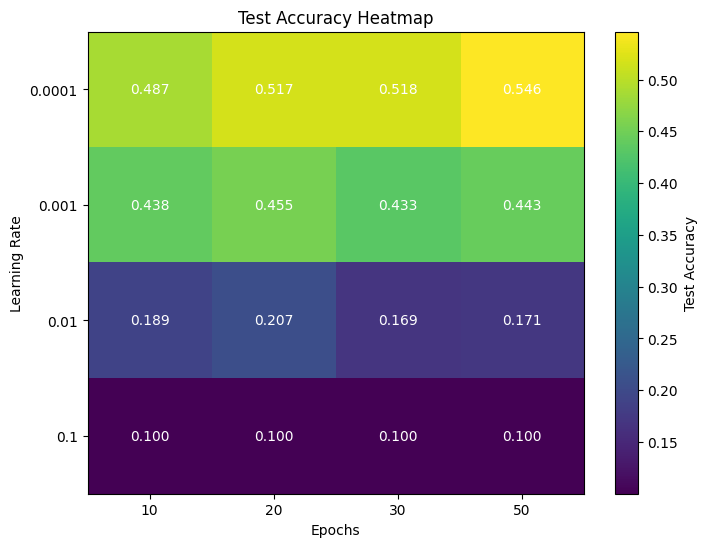


Best test accuracy: 0.5462 with LR=0.0001, epochs=50


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# ------------------------------
# 1. Load and prepare CIFAR-10
# ------------------------------
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten
x_train_full = x_train_full.reshape(-1, 3072)
x_test = x_test.reshape(-1, 3072)

# One-hot labels
y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Train/validation split
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full,
                                                  test_size=0.2, random_state=42)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# ------------------------------
# 2. MLP model builder
# ------------------------------
def build_mlp(hidden_units=[512, 256], dropout_rate=0.2):
    model = keras.Sequential()
    model.add(layers.Input(shape=(3072,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))
    return model

# ------------------------------
# 3. Training function with history storage
# ------------------------------
def train_and_evaluate(lr, epochs, batch_size=64):
    model = build_mlp()
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(x_train, y_train,
                        validation_data=(x_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0)   # silent training
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return history, test_acc

# ------------------------------
# 4. Grid search
# ------------------------------
learning_rates = [0.0001, 0.001, 0.01, 0.1]
epochs_list = [10, 20, 30, 50]
results = {}

for lr in learning_rates:
    for epochs in epochs_list:
        print(f"Training with LR={lr}, epochs={epochs}")
        history, test_acc = train_and_evaluate(lr, epochs)
        results[(lr, epochs)] = {
            'test_acc': test_acc,
            'train_acc_history': history.history['accuracy'],
            'val_acc_history': history.history['val_accuracy']
        }

# ------------------------------
# 5. Plot training curves
# ------------------------------

# 5.1 Effect of learning rate (fix epochs=30)
plt.figure(figsize=(10, 6))
for lr in learning_rates:
    key = (lr, 30)
    if key in results:
        val_acc = results[key]['val_acc_history']
        plt.plot(range(1, len(val_acc)+1), val_acc, label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Learning Rate (30 epochs)')
plt.legend()
plt.grid(True)
plt.savefig('lr_effect.png')
plt.show()

# 5.2 Effect of number of epochs (fix LR=0.001, the best)
plt.figure(figsize=(10, 6))
for epochs in epochs_list:
    key = (0.001, epochs)
    if key in results:
        val_acc = results[key]['val_acc_history']
        plt.plot(range(1, len(val_acc)+1), val_acc, label=f'Epochs={epochs}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Training Duration (LR=0.001)')
plt.legend()
plt.grid(True)
plt.savefig('epochs_effect.png')
plt.show()

# 5.3 Training vs validation curve for the best combination (LR=0.001, epochs=30)
best_key = (0.001, 30)
train_acc = results[best_key]['train_acc_history']
val_acc = results[best_key]['val_acc_history']
epochs_range = range(1, len(train_acc)+1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (LR=0.001, epochs=30)')
plt.legend()
plt.grid(True)
plt.savefig('train_val_curve.png')
plt.show()

# 5.4 Heatmap of test accuracy across all combinations
test_acc_matrix = np.zeros((len(learning_rates), len(epochs_list)))
for i, lr in enumerate(learning_rates):
    for j, ep in enumerate(epochs_list):
        test_acc_matrix[i, j] = results[(lr, ep)]['test_acc']

plt.figure(figsize=(8, 6))
plt.imshow(test_acc_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Test Accuracy')
plt.xticks(range(len(epochs_list)), epochs_list)
plt.yticks(range(len(learning_rates)), learning_rates)
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Test Accuracy Heatmap')
for i in range(len(learning_rates)):
    for j in range(len(epochs_list)):
        plt.text(j, i, f'{test_acc_matrix[i, j]:.3f}',
                 ha='center', va='center', color='white')
plt.savefig('test_acc_heatmap.png')
plt.show()

# Print best test accuracy
best_acc = 0.0
best_params = None
for (lr, ep), res in results.items():
    if res['test_acc'] > best_acc:
        best_acc = res['test_acc']
        best_params = (lr, ep)
print(f"\nBest test accuracy: {best_acc:.4f} with LR={best_params[0]}, epochs={best_params[1]}")